In [6]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# 📌 Step 2: Load dataset
# Try semicolon (original UCI Bank Marketing dataset uses this)
df = pd.read_csv("/content/bank-full.csv", sep=";")

# If still one column, try comma
if df.shape[1] == 1:
    df = pd.read_csv("/content/bank-full.csv", sep=",")

# Show shape and first rows
print("Fixed df shape:", df.shape)
print(df.head())

Fixed df shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome class  
0  unknown    5   may       261         1     -1         0  unknown    no  
1  unknown    5   may       151         1     -1         0  unknown    no  
2  unknown    5   may        76         1     -1         0  unknown    no  
3  unknown    5   may        92         1     -1         0  unknown    no  
4  unknown    5   may       198         1     -1         0  unknown    no  


In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df.copy()

# Encode categorical columns
categorical_cols = df_processed.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(df_processed)

print("Scaled data shape:", X.shape)  # should be (45211, 17)

Scaled data shape: (45211, 17)


In [8]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02, random_state=42)
df["is_anomaly"] = iso.fit_predict(X)

# Convert -1 → anomaly, 1 → normal
df["is_anomaly"] = df["is_anomaly"].map({1: False, -1: True})

print(df["is_anomaly"].value_counts())

is_anomaly
False    44306
True       905
Name: count, dtype: int64


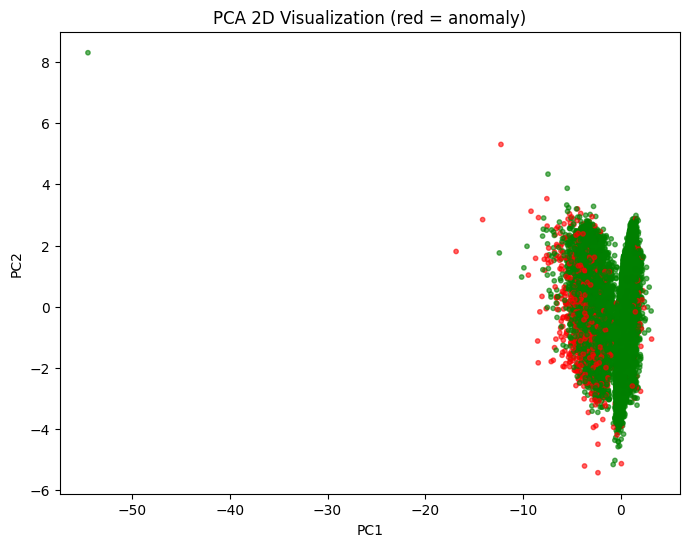

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X)

df_vis = pd.DataFrame(pcs, columns=["PC1", "PC2"])
df_vis["is_anomaly"] = df["is_anomaly"]

plt.figure(figsize=(8,6))
plt.scatter(df_vis["PC1"], df_vis["PC2"],
            c=df_vis["is_anomaly"].map({False:"green", True:"red"}),
            s=10, alpha=0.6)
plt.title("PCA 2D Visualization (red = anomaly)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

In [10]:
# Step 6: Reporting & Insights

print("===== Anomaly Detection Report =====")

# Total anomalies
total = len(df)
anomalies = df['is_anomaly'].sum()
print(f"Total records: {total}")
print(f"Anomalies detected: {anomalies} ({anomalies/total:.2%})")

# Distribution by job
print("\nTop 5 jobs with highest anomaly counts:")
print(df[df['is_anomaly']].groupby('job').size().sort_values(ascending=False).head())

# Distribution by education
print("\nAnomalies by education level:")
print(df[df['is_anomaly']].groupby('education').size().sort_values(ascending=False))

# Balance statistics
print("\nBalance summary (normal vs anomalies):")
print(df.groupby('is_anomaly')['balance'].describe())

# Age distribution
print("\nAge summary (normal vs anomalies):")
print(df.groupby('is_anomaly')['age'].describe())

print("\n✅ Report complete. Use this to explain which groups are more likely to be flagged as anomalies.")


===== Anomaly Detection Report =====
Total records: 45211
Anomalies detected: 905 (2.00%)

Top 5 jobs with highest anomaly counts:
job
technician     158
blue-collar    145
management     135
retired        109
admin.         106
dtype: int64

Anomalies by education level:
education
secondary    327
tertiary     214
primary      196
unknown      168
dtype: int64

Balance summary (normal vs anomalies):
              count         mean          std     min    25%    50%     75%  \
is_anomaly                                                                    
False       44306.0  1335.441859  2939.737908 -8019.0   72.0  444.0  1409.0   
True          905.0  2675.795580  6190.560328 -1329.0  115.0  757.0  2785.0   

                 max  
is_anomaly            
False       102127.0  
True         81204.0  

Age summary (normal vs anomalies):
              count       mean        std   min   25%   50%   75%   max
is_anomaly                                                             
False 

===== Anomaly Detection Report =====
Total records: 45211
Anomalies detected: 905 (2.00%)


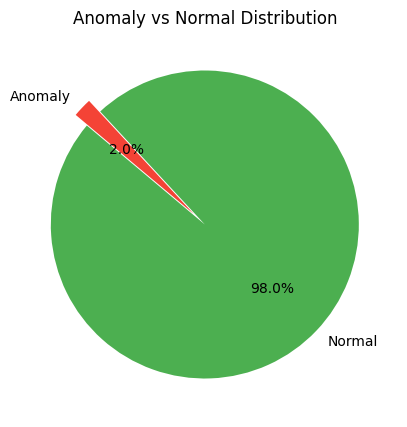


Top 5 jobs with highest anomaly counts:
job
technician     158
blue-collar    145
management     135
retired        109
admin.         106
dtype: int64


/tmp/ipython-input-415055085.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_counts.index, y=job_counts.values, palette="Reds_r")


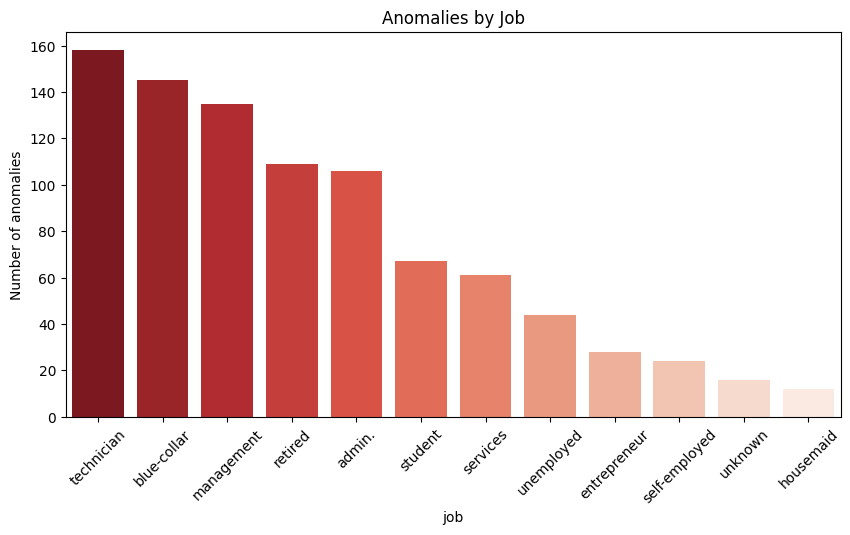


Anomalies by education level:
education
secondary    327
tertiary     214
primary      196
unknown      168
dtype: int64


/tmp/ipython-input-415055085.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_counts.index, y=edu_counts.values, palette="Blues_r")


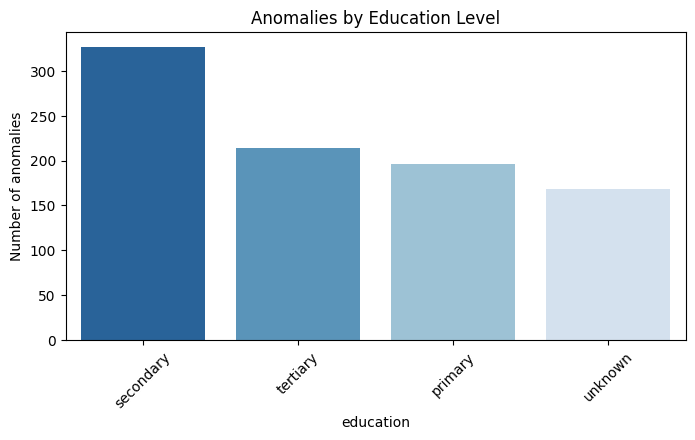


Balance summary (normal vs anomalies):
              count         mean          std     min    25%    50%     75%  \
is_anomaly                                                                    
False       44306.0  1335.441859  2939.737908 -8019.0   72.0  444.0  1409.0   
True          905.0  2675.795580  6190.560328 -1329.0  115.0  757.0  2785.0   

                 max  
is_anomaly            
False       102127.0  
True         81204.0  

Age summary (normal vs anomalies):
              count       mean        std   min   25%   50%   75%   max
is_anomaly                                                             
False       44306.0  40.861012  10.482985  18.0  33.0  39.0  48.0  95.0
True          905.0  44.617680  15.474419  18.0  32.0  42.0  55.0  95.0

✅ Report complete with visuals.


In [12]:
# Step 6: Reporting & Insights with Visuals
import seaborn as sns
import matplotlib.pyplot as plt

print("===== Anomaly Detection Report =====")

# 1. Total anomalies
total = len(df)
anomalies = df['is_anomaly'].sum()
print(f"Total records: {total}")
print(f"Anomalies detected: {anomalies} ({anomalies/total:.2%})")

# Pie chart: anomaly vs normal
labels = ["Normal", "Anomaly"]
sizes = [total - anomalies, anomalies]
colors = ["#4CAF50", "#F44336"]
plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140, colors=colors, explode=(0,0.1))
plt.title("Anomaly vs Normal Distribution")
plt.show()

# 2. Jobs with highest anomaly counts
job_counts = df[df['is_anomaly']].groupby('job').size().sort_values(ascending=False)
print("\nTop 5 jobs with highest anomaly counts:")
print(job_counts.head())

plt.figure(figsize=(10,5))
sns.barplot(x=job_counts.index, y=job_counts.values, palette="Reds_r")
plt.title("Anomalies by Job")
plt.ylabel("Number of anomalies")
plt.xticks(rotation=45)
plt.show()

# 3. Education-level anomalies
edu_counts = df[df['is_anomaly']].groupby('education').size().sort_values(ascending=False)
print("\nAnomalies by education level:")
print(edu_counts)

plt.figure(figsize=(8,4))
sns.barplot(x=edu_counts.index, y=edu_counts.values, palette="Blues_r")
plt.title("Anomalies by Education Level")
plt.ylabel("Number of anomalies")
plt.xticks(rotation=45)
plt.show()

# 4. Balance statistics
print("\nBalance summary (normal vs anomalies):")
print(df.groupby('is_anomaly')['balance'].describe())

# 5. Age statistics
print("\nAge summary (normal vs anomalies):")
print(df.groupby('is_anomaly')['age'].describe())

print("\n✅ Report complete with visuals.")